# GP Multi-task ICM Tutorial

Purpose: jointly model correlated outputs (deflection and slope) with shared structure.


## Learning Roadmap

- Understand when multi-output coupling helps over independent models.
- Inspect learned task correlation matrix from ICM.
- Compare uncertainty profiles across tasks.


In [1]:
# Step 1: import multitask GP model and plotting tools
# Configure Python path for local package imports
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'gp' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

from deepuq.models import MultiTaskGaussianProcessRegressor, RBFKernel


In [2]:
# Step 2: create correlated deflection/slope targets
x_train = torch.linspace(-3.8, 3.8, 70).unsqueeze(-1)

deflection = 0.6 * torch.sin(1.1 * x_train) + 0.03 * x_train**2
slope = torch.gradient(deflection.squeeze(-1), spacing=(x_train.squeeze(-1),))[0].unsqueeze(-1)

y_train = torch.cat([
    deflection + 0.08 * torch.randn_like(deflection),
    slope + 0.06 * torch.randn_like(slope),
], dim=1)

x_test = torch.linspace(-5, 5, 250).unsqueeze(-1)


In [3]:
# Step 3: fit ICM model and inspect learned task correlation
mtgp = MultiTaskGaussianProcessRegressor(
    num_tasks=2,
    kernel=RBFKernel(lengthscale=0.85, outputscale=1.0),
    opt_steps=180,
    lr=0.04,
)
mtgp.fit(x_train, y_train)
uq = mtgp.predict_uq(x_test)
print('task_correlation matrix:', uq.metadata['task_correlation'])


task_correlation matrix: tensor([[ 1.0000, -0.1300],
        [-0.1300,  1.0000]])


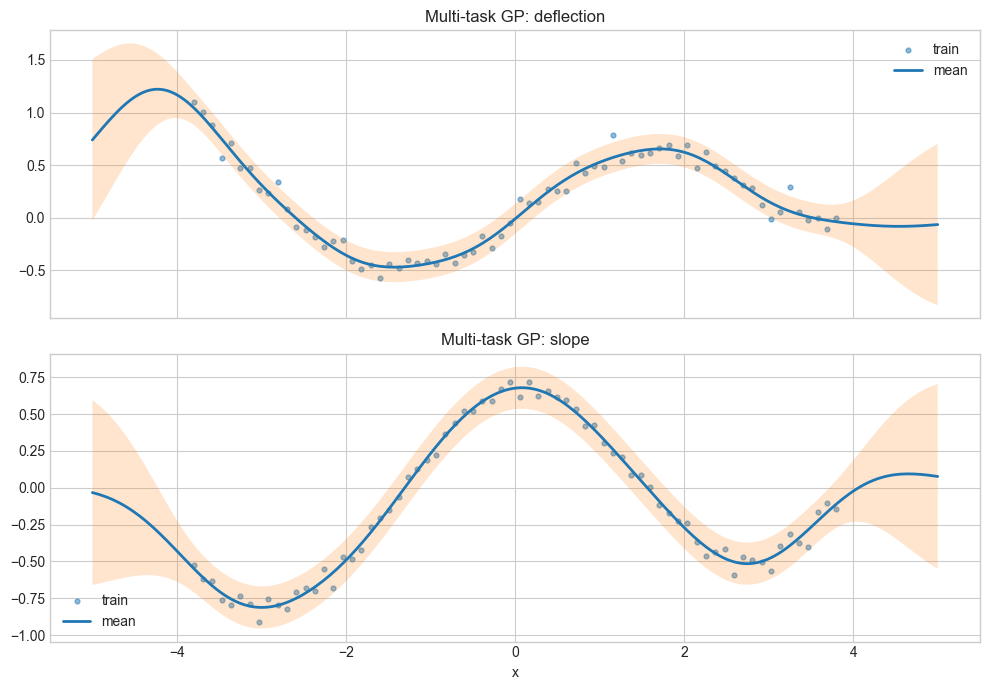

In [4]:
# Step 4: visualize per-task posterior with uncertainty bands
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
task_names = ['deflection', 'slope']
for t in range(2):
    std = torch.sqrt(uq.total_var[:, t])
    axes[t].scatter(x_train.numpy(), y_train[:, t].numpy(), s=12, alpha=0.5, label='train')
    axes[t].plot(x_test.numpy(), uq.mean[:, t].numpy(), lw=2, label='mean')
    axes[t].fill_between(
        x_test.squeeze(-1).numpy(),
        (uq.mean[:, t] - 1.96 * std).numpy(),
        (uq.mean[:, t] + 1.96 * std).numpy(),
        alpha=0.2,
    )
    axes[t].set_title(f'Multi-task GP: {task_names[t]}')
    axes[t].legend(loc='best')
axes[-1].set_xlabel('x')
plt.tight_layout()
plt.show()


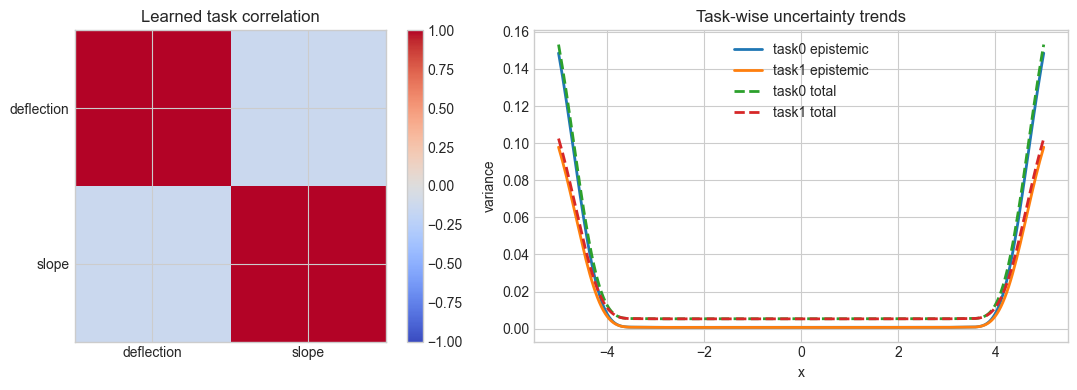

In [5]:
# Additional diagnostic: task-correlation heatmap and variance trends
corr = uq.metadata['task_correlation']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set_title('Learned task correlation')
axes[0].set_xticks([0, 1], labels=['deflection', 'slope'])
axes[0].set_yticks([0, 1], labels=['deflection', 'slope'])
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(x_test.numpy(), uq.epistemic_var[:, 0].numpy(), lw=2, label='task0 epistemic')
axes[1].plot(x_test.numpy(), uq.epistemic_var[:, 1].numpy(), lw=2, label='task1 epistemic')
axes[1].plot(x_test.numpy(), uq.total_var[:, 0].numpy(), '--', lw=2, label='task0 total')
axes[1].plot(x_test.numpy(), uq.total_var[:, 1].numpy(), '--', lw=2, label='task1 total')
axes[1].set_title('Task-wise uncertainty trends')
axes[1].set_xlabel('x')
axes[1].set_ylabel('variance')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()
